# Testing
## Bevölkerung nach Monat, Stadtquartier, Geschlecht, Altersgruppe und Herkunft, seit 1998
Datum: 16.08.2024

### Kurzbeschreibung
Beschreibung
Anzahl wirtschaftliche Bevölkerung nach Monat, Altersgruppe, Geschlecht, Herkunft, Stadtkreis und Stadtquartier.

Im aktuellen Jahr handelt es sich um provisorische Daten. Diese können laufend korrigiert werden. Erst mit dem Jahresabschluss werden die Daten definitiv.



Dataset auf PROD-Datakatalog: Link https://data.stadt-zuerich.ch/dataset/bev_monat_bestand_quartier_geschl_ag_herkunft_od3250

Dataset auf INTEG-Datakatalog: Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_monat_bestand_quartier_geschl_ag_herkunft_od3250

### Importiere die notwendigen Packages

In [31]:
#%pip install altair folium geopandas matplotlib numpy pandas plotly requests seaborn

In [32]:
import altair as alt
import datetime
import folium 
import geopandas as gpd
import io
from IPython.display import Markdown as md
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import pivottablejs
#from pivottablejs import pivot_ui
import plotly.express as px
import requests
import seaborn as sns

Importiere die eigenen Funktionen, die unter ../0_scripts abegelegt sind:

In [33]:
import sys
sys.path.append('../0_scripts')

import my_py_dataviz_functions as mypy_dv
import my_py_dataloading_functions as mypy_dl

In [34]:
SSL_VERIFY = False
# evtl. SSL_VERIFY auf False setzen wenn die Verbindung zu https://www.gemeinderat-zuerich.ch nicht klappt (z.B. wegen Proxy)
# Um die SSL Verifikation auszustellen, bitte die nächste Zeile einkommentieren ("#" entfernen)
# SSL_VERIFY = False

In [35]:
if not SSL_VERIFY:
    import urllib3
    urllib3.disable_warnings()

### Settings
Definiere Settings. 
Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen)

In [36]:
#pd.options.display.float_format = lambda x : '{:,.1f}'.format(x) if (np.isnan(x) | np.isinf(x)) else '{:,.0f}'.format(x) if int(x) == x else '{:,.1f}'.format(x)
pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

#### Zeitvariabeln


In [37]:
#Zeitvariabeln als Strings:
now = datetime.date.today()
year_today = now.strftime("%Y")
date_today = "_"+now.strftime("%Y-%m-%d")

#Zeitvariabeln als Integers:
int_times = now.timetuple()
aktuellesJahr = int_times[0]
aktuellerMonat = int_times[1]
selectedMonat = int_times[1]-2
#print(aktuellesJahr, aktuellerMonat,'datenstand: ', selectedMonat, int_times)

### Daten importieren und Metadaten checken

- status: int / prod
- data_source: web / ld / dropzone
- datums_attr: beschreibt das oder die Datumsfelder, die als Datum geparsed werden sollen. Falls es keines gibt: None

In [38]:
package_name = "bev_monat_bestand_quartier_geschl_ag_herkunft_od3250"

In [39]:
data2betested = mypy_dl.load_data(
    status = 'int'
    , data_source = 'web'
    , package_name = package_name
    , dataset_name = "BEV325OD3250"    
    , datums_attr = ['StichtagDatJahr','StichtagDat']
    )

fp lautet:https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_monat_bestand_quartier_geschl_ag_herkunft_od3250/download/BEV325OD3250.csv


 **Überprüfe die Metadaten:**

 **Dataset auf INTEG-Datakatalog:** Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_monat_bestand_quartier_geschl_ag_herkunft_od3250 

 **Dataset auf PROD-Datakatalog:** Link https://data.stadt-zuerich.ch/dataset/bev_monat_bestand_quartier_geschl_ag_herkunft_od3250 

data_source: web


In [40]:
data2betested.tail(2).T

,226902,226903
StichtagDatJahr,2025-01-01 00:00:00,2025-01-01 00:00:00
StichtagDatMM,10,10
StichtagDatMonat,Oktober,Oktober
StichtagDat,2025-10-31 00:00:00,2025-10-31 00:00:00
SexCd,2,2
SexLang,weiblich,weiblich
AlterV20ueber80Sort_noDM,5,5
AlterV20ueber80Cd_noDM,5,5
AlterV20ueber80Kurz_noDM,80 u. älter,80 u. älter
HerkunftCd,2,2


Berechne weitere Attribute falls notwendig

In [41]:
data2betested = (
    data2betested
    .copy()
    .assign(
        #Aktualisierungs_Datum_str= lambda x: x.Aktualisierungs_Datum.astype(str),
        StichtagDat_str = lambda x: x.StichtagDat.astype(str),
        Jahr = lambda x: x.StichtagDatJahr,
        Jahr_nbr = lambda x: x.Jahr.dt.year,
    )
    .sort_values('StichtagDatJahr', ascending=False)
    )
data2betested.dtypes

StichtagDatJahr             datetime64[ns]
StichtagDatMM                        int64
StichtagDatMonat                    object
StichtagDat                 datetime64[ns]
SexCd                                int64
SexLang                             object
AlterV20ueber80Sort_noDM             int64
AlterV20ueber80Cd_noDM               int64
AlterV20ueber80Kurz_noDM            object
HerkunftCd                           int64
HerkunftLang                        object
KreisCd                              int64
KreisLang                           object
QuarCd                               int64
QuarLang                            object
DatenstandCd                        object
DatenstandLang                      object
AnzBestWir                           int64
StichtagDat_str                     object
Jahr                        datetime64[ns]
Jahr_nbr                             int32
dtype: object

Minimales und maximales Jahr im Datensatz

In [42]:
data_max_date = max(data2betested.StichtagDat).strftime('%Y-%m-%d')
data_min_date = min(data2betested.StichtagDat).strftime('%Y-%m-%d')


print(f"Die Daten haben ein Minimumjahr von {data_min_date} und ein Maximumjahr von {data_max_date}")

Die Daten haben ein Minimumjahr von 1998-01-31 und ein Maximumjahr von 2025-10-31


### Einfache Datentests

In [43]:
data2betested.sort_values('StichtagDat', ascending=False).head(2).T

,226903,226837
StichtagDatJahr,2025-01-01 00:00:00,2025-01-01 00:00:00
StichtagDatMM,10,10
StichtagDatMonat,Oktober,Oktober
StichtagDat,2025-10-31 00:00:00,2025-10-31 00:00:00
SexCd,2,2
SexLang,weiblich,weiblich
AlterV20ueber80Sort_noDM,5,5
AlterV20ueber80Cd_noDM,5,5
AlterV20ueber80Kurz_noDM,80 u. älter,80 u. älter
HerkunftCd,2,1


In [44]:
#data2betested.dtypes
data2betested.info(memory_usage='deep', verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 226904 entries, 226903 to 0
Data columns (total 21 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   StichtagDatJahr           226904 non-null  datetime64[ns]
 1   StichtagDatMM             226904 non-null  int64         
 2   StichtagDatMonat          226904 non-null  object        
 3   StichtagDat               226904 non-null  datetime64[ns]
 4   SexCd                     226904 non-null  int64         
 5   SexLang                   226904 non-null  object        
 6   AlterV20ueber80Sort_noDM  226904 non-null  int64         
 7   AlterV20ueber80Cd_noDM    226904 non-null  int64         
 8   AlterV20ueber80Kurz_noDM  226904 non-null  object        
 9   HerkunftCd                226904 non-null  int64         
 10  HerkunftLang              226904 non-null  object        
 11  KreisCd                   226904 non-null  int64         
 12  KreisLa

In [45]:
print(f'The dataset has {data2betested.shape[0]:,.0f} rows (observations) and {data2betested.shape[1]:,.0f} columns (variables).')
print(f'There seem to be {data2betested.duplicated().sum()} exact duplicates in the data.')

The dataset has 226,904 rows (observations) and 21 columns (variables).
There seem to be 0 exact duplicates in the data.


In [46]:
data2betested.describe()

,StichtagDatJahr,StichtagDatMM,StichtagDat,SexCd,AlterV20ueber80Sort_noDM,AlterV20ueber80Cd_noDM,HerkunftCd,KreisCd,QuarCd,AnzBestWir,Jahr,Jahr_nbr
count,226904,226904,226904,226904,226904,226904,226904,226904,226904,226904,226904,226904
mean,2011-06-14 16:08:33.923068928,6,2011-12-26 21:00:57.878221824,2,3,3,1,6,66,584,2011-06-14 16:08:33.923068928,2011
min,1998-01-01 00:00:00,1,1998-01-31 00:00:00,1,1,1,1,1,11,0,1998-01-01 00:00:00,1998
25%,2004-01-01 00:00:00,3,2004-12-31 00:00:00,1,2,2,1,3,33,105,2004-01-01 00:00:00,2004
50%,2011-01-01 00:00:00,6,2011-12-31 00:00:00,2,3,3,1,7,71,383,2011-01-01 00:00:00,2011
75%,2018-01-01 00:00:00,9,2018-12-31 00:00:00,2,4,4,2,9,92,833,2018-01-01 00:00:00,2018
max,2025-01-01 00:00:00,12,2025-10-31 00:00:00,252,5,5,2,99,999,3798,2025-01-01 00:00:00,2025
std,NaN,3,NaN,1,1,1,0,5,52,628,NaN,8


Welches sind die Quartiere ohne Werte bei BEW?

In [47]:
data2betested[np.isnan(data2betested.AnzBestWir)]

,StichtagDatJahr,StichtagDatMM,StichtagDatMonat,StichtagDat,SexCd,SexLang,AlterV20ueber80Sort_noDM,...,QuarLang,DatenstandCd,DatenstandLang,AnzBestWir,StichtagDat_str,Jahr,Jahr_nbr


### Verwende das Datum als Index

While we did already parse the `datetime` column into the respective datetime type, it currently is just a regular column. 
**To enable quick and convenient queries and aggregations, we need to turn it into the index of the DataFrame**

In [48]:
data2betested = data2betested.set_index("StichtagDat")
data2betested = data2betested.sort_index()

In [49]:
data2betested.index.year.unique()

Index([1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012,
       2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025],
      dtype='int32', name='StichtagDat')

### Beschreibe einzelne Attribute

Beschreibe nicht numerische Attribute

In [50]:
# describe non-numerical features
try:
    with pd.option_context('display.float_format', '{:,.2f}'.format):
        display(data2betested.describe(exclude='number'))
except:
    print("No categorical data in dataset.")

,StichtagDatJahr,StichtagDatMonat,SexLang,AlterV20ueber80Kurz_noDM,HerkunftLang,KreisLang,QuarLang,DatenstandCd,DatenstandLang,StichtagDat_str,Jahr
count,226904,226904,226904,226904,226904,226904,226904,226904,226904,226904,226904
unique,NaN,12,3,5,2,13,35,2,2,334,NaN
top,NaN,Januar,weiblich,40-59,Schweizer*in,Kreis 7,Altstetten,V,Veröffentlicht,2022-02-28,NaN
freq,NaN,19030,113527,45532,113756,26720,6683,167390,167390,697,NaN
mean,2011-06-14 16:08:33.923068928,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011-06-14 16:08:33.923068928
min,1998-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1998-01-01 00:00:00
25%,2004-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2004-01-01 00:00:00
50%,2011-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011-01-01 00:00:00
75%,2018-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-01-01 00:00:00
max,2025-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-01 00:00:00


Beschreibe numerische Attribute

In [51]:
# describe numerical features
try:
    with pd.option_context('display.float_format', '{:,.0f}'.format):
        display(data2betested.describe(include='number'))
except:
    print("No numercial data in dataset.")

,StichtagDatMM,SexCd,AlterV20ueber80Sort_noDM,AlterV20ueber80Cd_noDM,HerkunftCd,KreisCd,QuarCd,AnzBestWir,Jahr_nbr
count,"226,904","226,904","226,904","226,904","226,904","226,904","226,904","226,904","226,904"
mean,6,2,3,3,1,6,66,584,"2,011"
std,3,1,1,1,0,5,52,628,8
min,1,1,1,1,1,1,11,0,"1,998"
25%,3,1,2,2,1,3,33,105,"2,004"
50%,6,2,3,3,1,7,71,383,"2,011"
75%,9,2,4,4,2,9,92,833,"2,018"
max,12,252,5,5,2,99,999,"3,798","2,025"


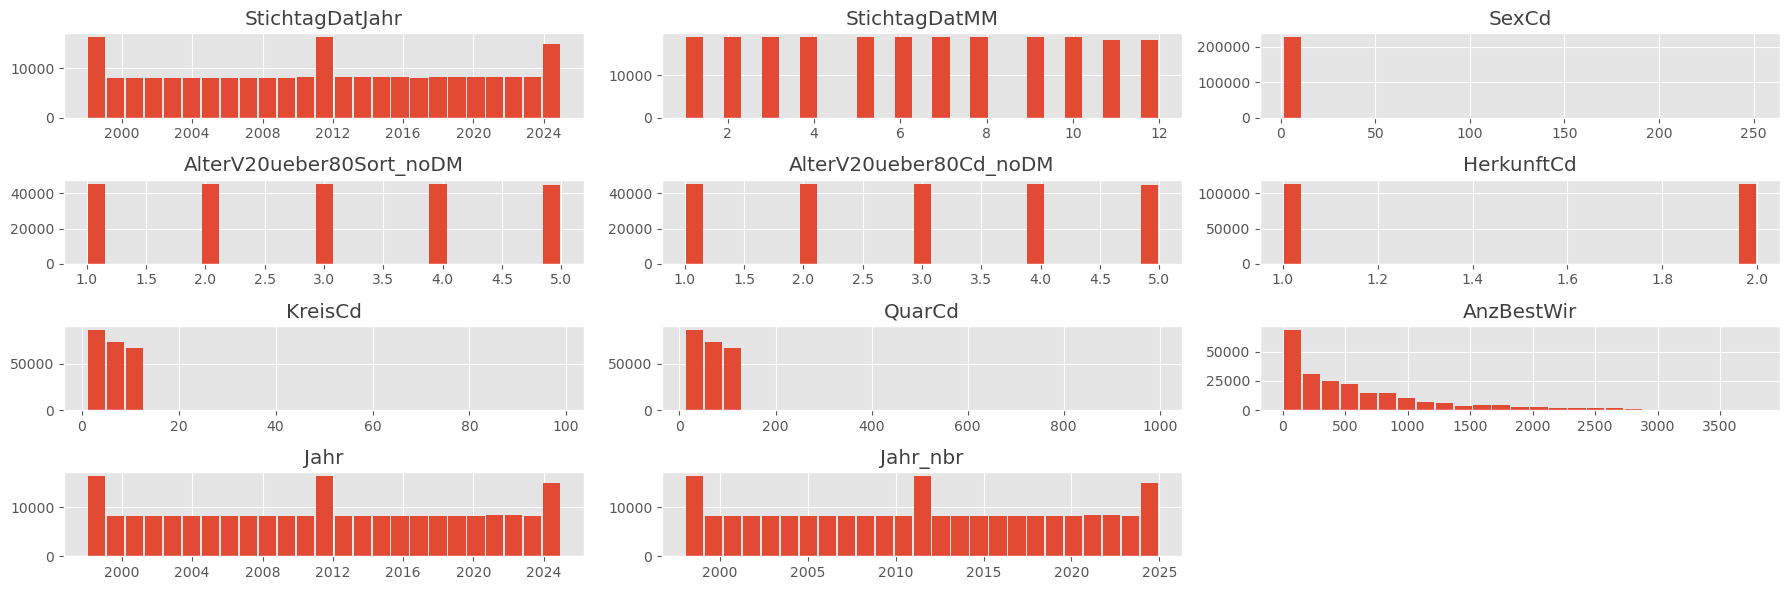

In [52]:
plt.style.use('ggplot')
params = {
    'text.color': (0.25, 0.25, 0.25),
    'figure.figsize': [18, 6],
   }
plt.rcParams.update(params)

try:
    data2betested.hist(bins=25, rwidth=0.9)
    plt.tight_layout()
    plt.show()
except:
    print("No numercial data to plot.") 

### Gibt es Duplikate?

In [53]:
# find duplicate rows
duplicate_rows = data2betested[data2betested.duplicated()]
duplicate_rows

,StichtagDatJahr,StichtagDatMM,StichtagDatMonat,SexCd,SexLang,AlterV20ueber80Sort_noDM,AlterV20ueber80Cd_noDM,...,QuarLang,DatenstandCd,DatenstandLang,AnzBestWir,StichtagDat_str,Jahr,Jahr_nbr
StichtagDat,,,,,,,,,,,,,,,


### Nullwerte und Missings?

In [54]:
data2betested.isnull().sum()

StichtagDatJahr             0
StichtagDatMM               0
StichtagDatMonat            0
SexCd                       0
SexLang                     0
AlterV20ueber80Sort_noDM    0
AlterV20ueber80Cd_noDM      0
AlterV20ueber80Kurz_noDM    0
HerkunftCd                  0
HerkunftLang                0
KreisCd                     0
KreisLang                   0
QuarCd                      0
QuarLang                    0
DatenstandCd                0
DatenstandLang              0
AnzBestWir                  0
StichtagDat_str             0
Jahr                        0
Jahr_nbr                    0
dtype: int64

In [55]:
# check missing values with missingno
# https://github.com/ResidentMario/missingno
#import missingno as msno
#msno.matrix(data2betested, labels=True, sort='descending');
#msno.heatmap(data2betested)

### Gruppierungen

In [56]:
agg_jahr = data2betested.loc[data_min_date:data_max_date].reset_index()\
    .groupby(['StichtagDat', 'StichtagDatMonat', 'Jahr_nbr']) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('StichtagDat', ascending=False) 
agg_jahr.reset_index().head(6)

,StichtagDat,StichtagDatMonat,Jahr_nbr,sum_AnzBestWir
0,2025-10-31,Oktober,2025,453126
1,2025-09-30,September,2025,452799
2,2025-08-31,August,2025,450508
3,2025-07-31,Juli,2025,450212
4,2025-06-30,Juni,2025,450486
5,2025-05-31,Mai,2025,450816


In [57]:
agg_herk = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['HerkunftCd', 'HerkunftLang']) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('HerkunftCd', ascending=False) 
agg_herk.reset_index().head(3)

,HerkunftCd,HerkunftLang,sum_AnzBestWir
0,2,Ausländer*in,41430475
1,1,Schweizer*in,91147739


In [58]:
agg_age = data2betested.loc[data_max_date]\
    .groupby(['StichtagDat','AlterV20ueber80Sort_noDM', 'AlterV20ueber80Kurz_noDM']) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('AlterV20ueber80Sort_noDM', ascending=True) 
agg_age.reset_index().head(11)

,StichtagDat,AlterV20ueber80Sort_noDM,AlterV20ueber80Kurz_noDM,sum_AnzBestWir
0,2025-10-31,1,0-19,78242
1,2025-10-31,2,20-39,165364
2,2025-10-31,3,40-59,125117
3,2025-10-31,4,60-79,63929
4,2025-10-31,5,80 u. älter,20474


In [59]:
agg_kreis_quart = data2betested.loc[data_max_date]\
    .groupby(['StichtagDat','KreisCd', 'KreisLang', 'QuarCd', 'QuarLang']) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('QuarCd', ascending=False) 
agg_kreis_quart.reset_index().head(6)

,StichtagDat,KreisCd,KreisLang,QuarCd,QuarLang,sum_AnzBestWir
0,2025-10-31,12,Kreis 12,123,Hirzenbach,12634
1,2025-10-31,12,Kreis 12,122,Schwamendingen-Mitte,11392
2,2025-10-31,12,Kreis 12,121,Saatlen,8866
3,2025-10-31,11,Kreis 11,119,Seebach,29409
4,2025-10-31,11,Kreis 11,115,Oerlikon,24250
5,2025-10-31,11,Kreis 11,111,Affoltern,27465


In [60]:
agg_dstand = data2betested.loc["2023-01":data_max_date]\
    .groupby(['StichtagDat','DatenstandCd','DatenstandLang']) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('StichtagDat', ascending=False) 
agg_dstand.reset_index().head(12)

,StichtagDat,DatenstandCd,DatenstandLang,sum_AnzBestWir
0,2025-10-31,P,Provisorisch,453126
1,2025-09-30,P,Provisorisch,452799
2,2025-08-31,P,Provisorisch,450508
3,2025-07-31,P,Provisorisch,450212
4,2025-06-30,P,Provisorisch,450486
5,2025-05-31,P,Provisorisch,450816
6,2025-04-30,P,Provisorisch,450295
7,2025-03-31,P,Provisorisch,449665
8,2025-02-28,P,Provisorisch,449526
9,2025-01-31,P,Provisorisch,448494


In [61]:
data2betested.columns

Index(['StichtagDatJahr', 'StichtagDatMM', 'StichtagDatMonat', 'SexCd', 'SexLang',
       'AlterV20ueber80Sort_noDM', 'AlterV20ueber80Cd_noDM', 'AlterV20ueber80Kurz_noDM',
       'HerkunftCd', 'HerkunftLang', 'KreisCd', 'KreisLang', 'QuarCd', 'QuarLang', 'DatenstandCd',
       'DatenstandLang', 'AnzBestWir', 'StichtagDat_str', 'Jahr', 'Jahr_nbr'],
      dtype='object')

### Visualisierungen nach Zeitausschnitten

In [62]:
data2betested.info()
#data2betested

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 226904 entries, 1998-01-31 to 2025-10-31
Data columns (total 20 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   StichtagDatJahr           226904 non-null  datetime64[ns]
 1   StichtagDatMM             226904 non-null  int64         
 2   StichtagDatMonat          226904 non-null  object        
 3   SexCd                     226904 non-null  int64         
 4   SexLang                   226904 non-null  object        
 5   AlterV20ueber80Sort_noDM  226904 non-null  int64         
 6   AlterV20ueber80Cd_noDM    226904 non-null  int64         
 7   AlterV20ueber80Kurz_noDM  226904 non-null  object        
 8   HerkunftCd                226904 non-null  int64         
 9   HerkunftLang              226904 non-null  object        
 10  KreisCd                   226904 non-null  int64         
 11  KreisLang                 226904 non-null  object

#### Entwicklung Wohnbevölkerung nach Stadtkreis

In [63]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
myAgg1 = data2betested \
    .groupby(['StichtagDat','StichtagDatJahr', 'StichtagDatMM','KreisLang', 'KreisCd']) \
    .agg(sum_WBev=('AnzBestWir', 'sum')) \
    .sort_values('sum_WBev', ascending=False) 

myAgg1.reset_index().sort_values('KreisCd', ascending=True).head(2)

,StichtagDat,StichtagDatJahr,StichtagDatMM,KreisLang,KreisCd,sum_WBev
3785,2001-10-31,2001-01-01,10,Kreis 1,1,5771
3758,1999-09-30,1999-01-01,9,Kreis 1,1,5806


In [64]:
grafik1 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg1.reset_index().query('sum_WBev>1').sort_values('KreisCd', ascending=True)
    ,x = 'StichtagDat:T'
    ,y = 'sum_WBev:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Personen'
    ,category = "KreisLang:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Wohnbevölkerung nach Stadtkreis, seit "+data_min_date
)
grafik1

alt.LayerChart(...)

#### Entwicklung nach Alter

In [65]:
data2betested.dtypes
data2betested.head(2)

,StichtagDatJahr,StichtagDatMM,StichtagDatMonat,SexCd,SexLang,AlterV20ueber80Sort_noDM,AlterV20ueber80Cd_noDM,...,QuarLang,DatenstandCd,DatenstandLang,AnzBestWir,StichtagDat_str,Jahr,Jahr_nbr
StichtagDat,,,,,,,,,,,,,,,
1998-01-31,1998-01-01,1,Januar,1,männlich,1,1,...,Rathaus,V,Veröffentlicht,114,1998-01-31,1998-01-01,1998
1998-01-31,1998-01-01,1,Januar,1,männlich,2,2,...,Fluntern,V,Veröffentlicht,846,1998-01-31,1998-01-01,1998


In [66]:
#myAgg = data2betested.loc[five_years_ago:latest_year] \
myAgg2 = data2betested.loc[data_min_date:data_max_date] \
    .groupby(['StichtagDat','StichtagDatJahr', 'StichtagDatMM', 'AlterV20ueber80Sort_noDM', 'AlterV20ueber80Kurz_noDM']) \
    .agg(sum_WBev=('AnzBestWir', 'sum')) \
    .sort_values('sum_WBev', ascending=False) 

myAgg2.reset_index().head(2)

,StichtagDat,StichtagDatJahr,StichtagDatMM,AlterV20ueber80Sort_noDM,AlterV20ueber80Kurz_noDM,sum_WBev
0,2025-10-31,2025-01-01,10,2,20-39,165364
1,2025-09-30,2025-01-01,9,2,20-39,165279


In [67]:
grafik2 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg2.reset_index().query('sum_WBev>100')
    ,x = 'StichtagDat:T'
    ,y = 'sum_WBev:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Personen'
    ,category = "AlterV20ueber80Kurz_noDM:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Wohnbevölkerung nach Altersgruppen, seit "+data_min_date
)
grafik2

alt.LayerChart(...)

#### Entwicklung nach Heimat

In [68]:
#myAgg = data2betested.loc["2008-11":"2021-11"] \
myAgg3 = data2betested.loc[data_min_date:data_max_date]  \
    .groupby(['StichtagDat','StichtagDatJahr', 'StichtagDatMM', 'HerkunftLang']) \
    .agg(sum_WBev=('AnzBestWir', 'sum')) \
    .sort_values('sum_WBev', ascending=False) 

myAgg3.reset_index().head(2)

,StichtagDat,StichtagDatJahr,StichtagDatMM,HerkunftLang,sum_WBev
0,2025-10-31,2025-01-01,10,Schweizer*in,298778
1,2025-09-30,2025-01-01,9,Schweizer*in,298220


In [69]:
grafik3 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg3.reset_index().query('sum_WBev>100')
    ,x = 'StichtagDat:T'
    ,y = 'sum_WBev:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Personen'
    ,category = "HerkunftLang:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Wohnbevölkerung nach Herkunft, seit "+data_min_date
)
grafik3

alt.LayerChart(...)

#### Faced Grids

In [70]:
sns.set_theme(style="whitegrid")

In [71]:
data2betested.columns

Index(['StichtagDatJahr', 'StichtagDatMM', 'StichtagDatMonat', 'SexCd', 'SexLang',
       'AlterV20ueber80Sort_noDM', 'AlterV20ueber80Cd_noDM', 'AlterV20ueber80Kurz_noDM',
       'HerkunftCd', 'HerkunftLang', 'KreisCd', 'KreisLang', 'QuarCd', 'QuarLang', 'DatenstandCd',
       'DatenstandLang', 'AnzBestWir', 'StichtagDat_str', 'Jahr', 'Jahr_nbr'],
      dtype='object')

In [72]:
#.query('HerkunftLang !="Ausland"')
myFG = data2betested\
    .groupby(['StichtagDat', 'Jahr_nbr', 'KreisCd', 'KreisLang','QuarLang', 'QuarCd','AlterV20ueber80Sort_noDM', 'AlterV20ueber80Kurz_noDM']) \
    .agg(sum_WBev=('AnzBestWir', 'sum')) \
    .sort_values('QuarCd', ascending=True) 
myFG.reset_index().head(2)

,StichtagDat,Jahr_nbr,KreisCd,KreisLang,QuarLang,QuarCd,AlterV20ueber80Sort_noDM,AlterV20ueber80Kurz_noDM,sum_WBev
0,2015-01-31,2015,1,Kreis 1,Rathaus,11,4,60-79,636
1,2015-05-31,2015,1,Kreis 1,Rathaus,11,4,60-79,632


In [73]:
bug_df = myFG.loc["2021"].reset_index().query("QuarLang in ['Unbekannt','Hirzenbach','Schwamendingen-Mitte','Friesenberg','Alt-Wiedikon']").sort_values('QuarCd', ascending=True)
bug_df = bug_df.query("KreisCd== 99 or QuarCd==999")
bug_df = bug_df.query("KreisLang!= QuarLang")


In [74]:
#bug_df = bug_df.sort_values(['QuarCd',"StichtagDat","AlterV20ueber80Sort_noDM"], ascending=[False, True, True])



In [75]:
bug_df

,StichtagDat,Jahr_nbr,KreisCd,KreisLang,QuarLang,QuarCd,AlterV20ueber80Sort_noDM,AlterV20ueber80Kurz_noDM,sum_WBev


In [76]:
#bug_df.to_excel('C:/Temp/bug1_bev_bestand_monat.xlsx')

In [77]:
bug2 = myFG.loc["2021"].query("sum_WBev < 100 and KreisLang != 'Unbekannt' and QuarLang != 'Unbekannt'")
bug2 = bug2.reset_index().sort_values("StichtagDat", ascending=True)
bug2


,StichtagDat,Jahr_nbr,KreisCd,KreisLang,QuarLang,QuarCd,AlterV20ueber80Sort_noDM,AlterV20ueber80Kurz_noDM,sum_WBev
19,2021-01-31,2021,1,Kreis 1,Hochschulen,12,4,60-79,94
111,2021-01-31,2021,99,Unbekannt (Stadt Zürich),Unbekannt (Stadt Zürich),999,1,0-19,11
112,2021-01-31,2021,99,Unbekannt (Stadt Zürich),Unbekannt (Stadt Zürich),999,4,60-79,36
52,2021-01-31,2021,1,Kreis 1,City,14,5,80 u. älter,23
27,2021-01-31,2021,1,Kreis 1,Lindenhof,13,5,80 u. älter,51
...,...,...,...,...,...,...,...,...,...
54,2021-12-31,2021,1,Kreis 1,City,14,5,80 u. älter,21
5,2021-12-31,2021,1,Kreis 1,Hochschulen,12,1,0-19,70
4,2021-12-31,2021,1,Kreis 1,Hochschulen,12,5,80 u. älter,76
72,2021-12-31,2021,5,Kreis 5,Escher Wyss,52,5,80 u. älter,61


In [78]:
#print( mypy_dv.plot_sns_facetgrid.__doc__)

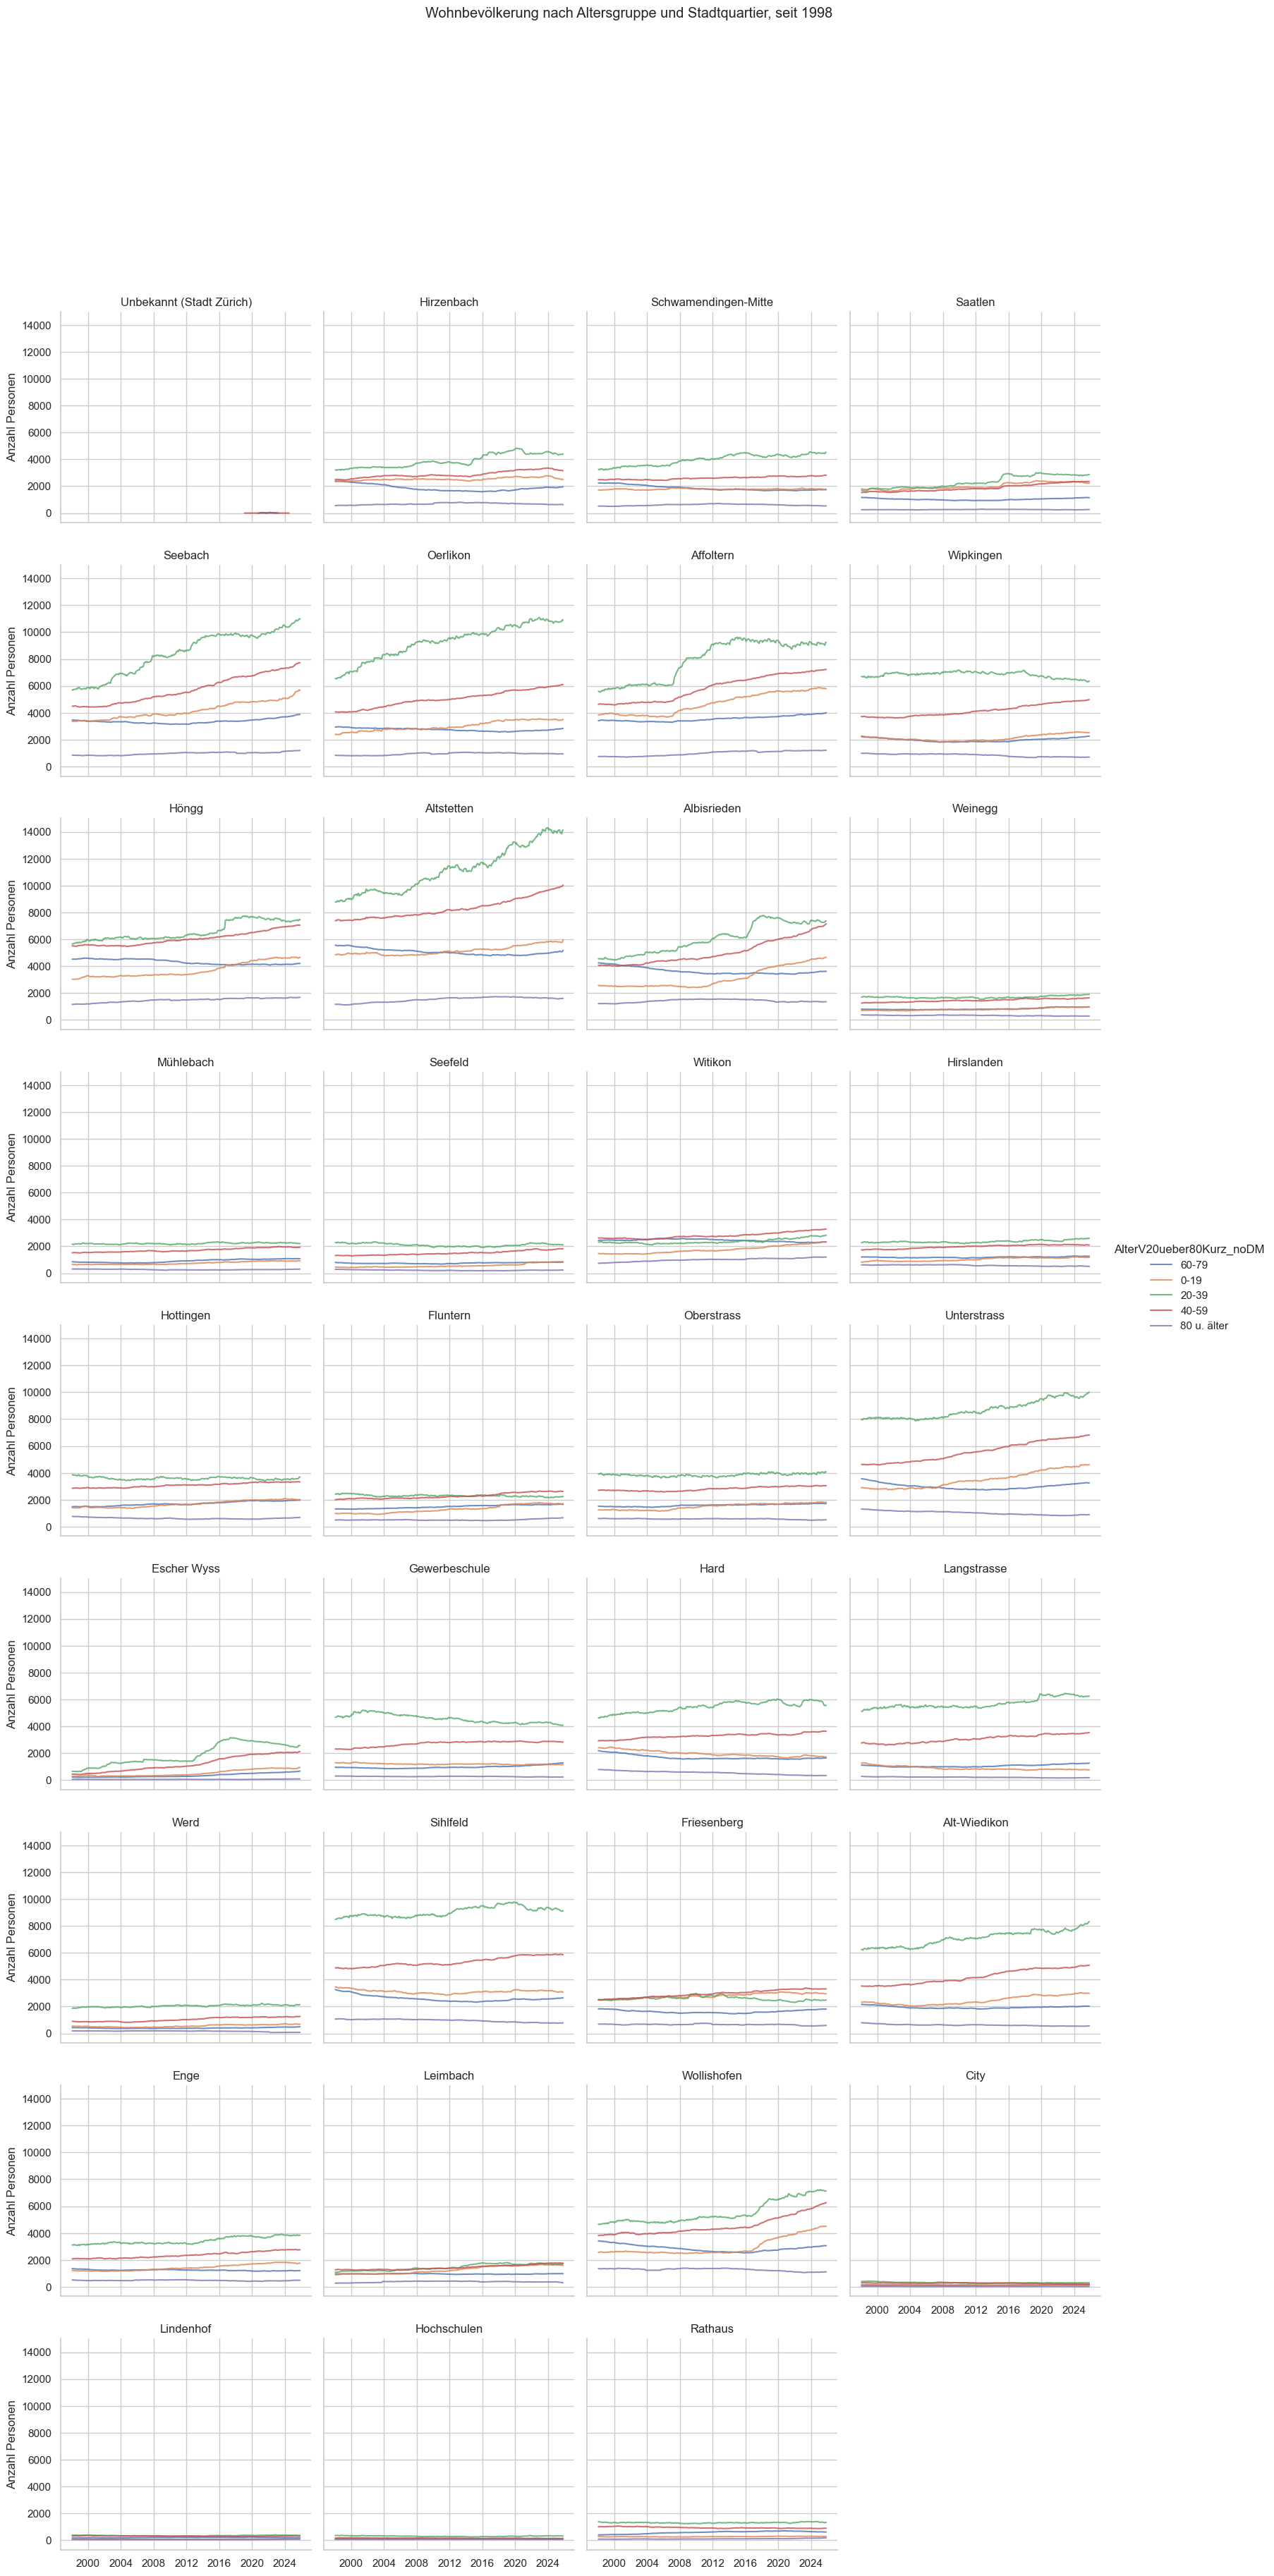

In [79]:
faced_grid1 = mypy_dv.plot_sns_facetgrid(
    data = myFG.reset_index().sort_values('QuarCd', ascending=False)
    ,col = "QuarLang"
    ,hue = "AlterV20ueber80Kurz_noDM"
    ,col_wrap = 4
    ,grafiktyp = sns.lineplot
    ,x = "StichtagDat"
    ,y = "sum_WBev"
    ,ylabel= "Anzahl Personen"
    ,warning_status ="ignore"
    ,height = 3
    ,myTitle="Wohnbevölkerung nach Altersgruppe und Stadtquartier, seit "+str(int(data2betested.index.year.min()))   
)
faced_grid1

##### Gibt es zeitliche Datenlücken?

In [80]:
#Gibt es eine zeitliche Datenlücke?

timefilter = "2025"
#lücke in der zeitreihe?
ideal_time_range = pd.date_range(start=data2betested.loc[timefilter].index.min(), end=data2betested.loc[timefilter].index.max(), freq='1m') #10h

# Überprüfe, ob es Unterschiede zwischen dem idealen Zeitstempelbereich und dem tatsächlichen Index gibt
missing_timestamps_my = ideal_time_range.difference(data2betested.index)

if missing_timestamps_my.empty:
    print("Keine Lücken in der Zeitreihe gefunden.")
else:
    print("Lücken in der Zeitreihe gefunden:")
    print(missing_timestamps_my)

Keine Lücken in der Zeitreihe gefunden.


#### Faced Grids

In [81]:
myFG2 = data2betested\
    .groupby(['StichtagDat', 'KreisCd', 'KreisLang','AlterV20ueber80Sort_noDM', 'AlterV20ueber80Kurz_noDM']) \
    .agg(sum_WBev=('AnzBestWir', 'sum')) \
    .sort_values('KreisCd', ascending=True) 
myFG2.reset_index()

,StichtagDat,KreisCd,KreisLang,AlterV20ueber80Sort_noDM,AlterV20ueber80Kurz_noDM,sum_WBev
0,1998-01-31,1,Kreis 1,1,0-19,575
1,2012-05-31,1,Kreis 1,4,60-79,1035
2,2012-05-31,1,Kreis 1,5,80 u. älter,261
3,2012-06-30,1,Kreis 1,1,0-19,518
4,2012-06-30,1,Kreis 1,2,20-39,2122
...,...,...,...,...,...,...
20167,2021-06-30,99,Unbekannt (Stadt Zürich),5,80 u. älter,1
20168,2021-01-31,99,Unbekannt (Stadt Zürich),4,60-79,36
20169,2021-01-31,99,Unbekannt (Stadt Zürich),3,40-59,32
20170,2022-01-31,99,Unbekannt (Stadt Zürich),1,0-19,15


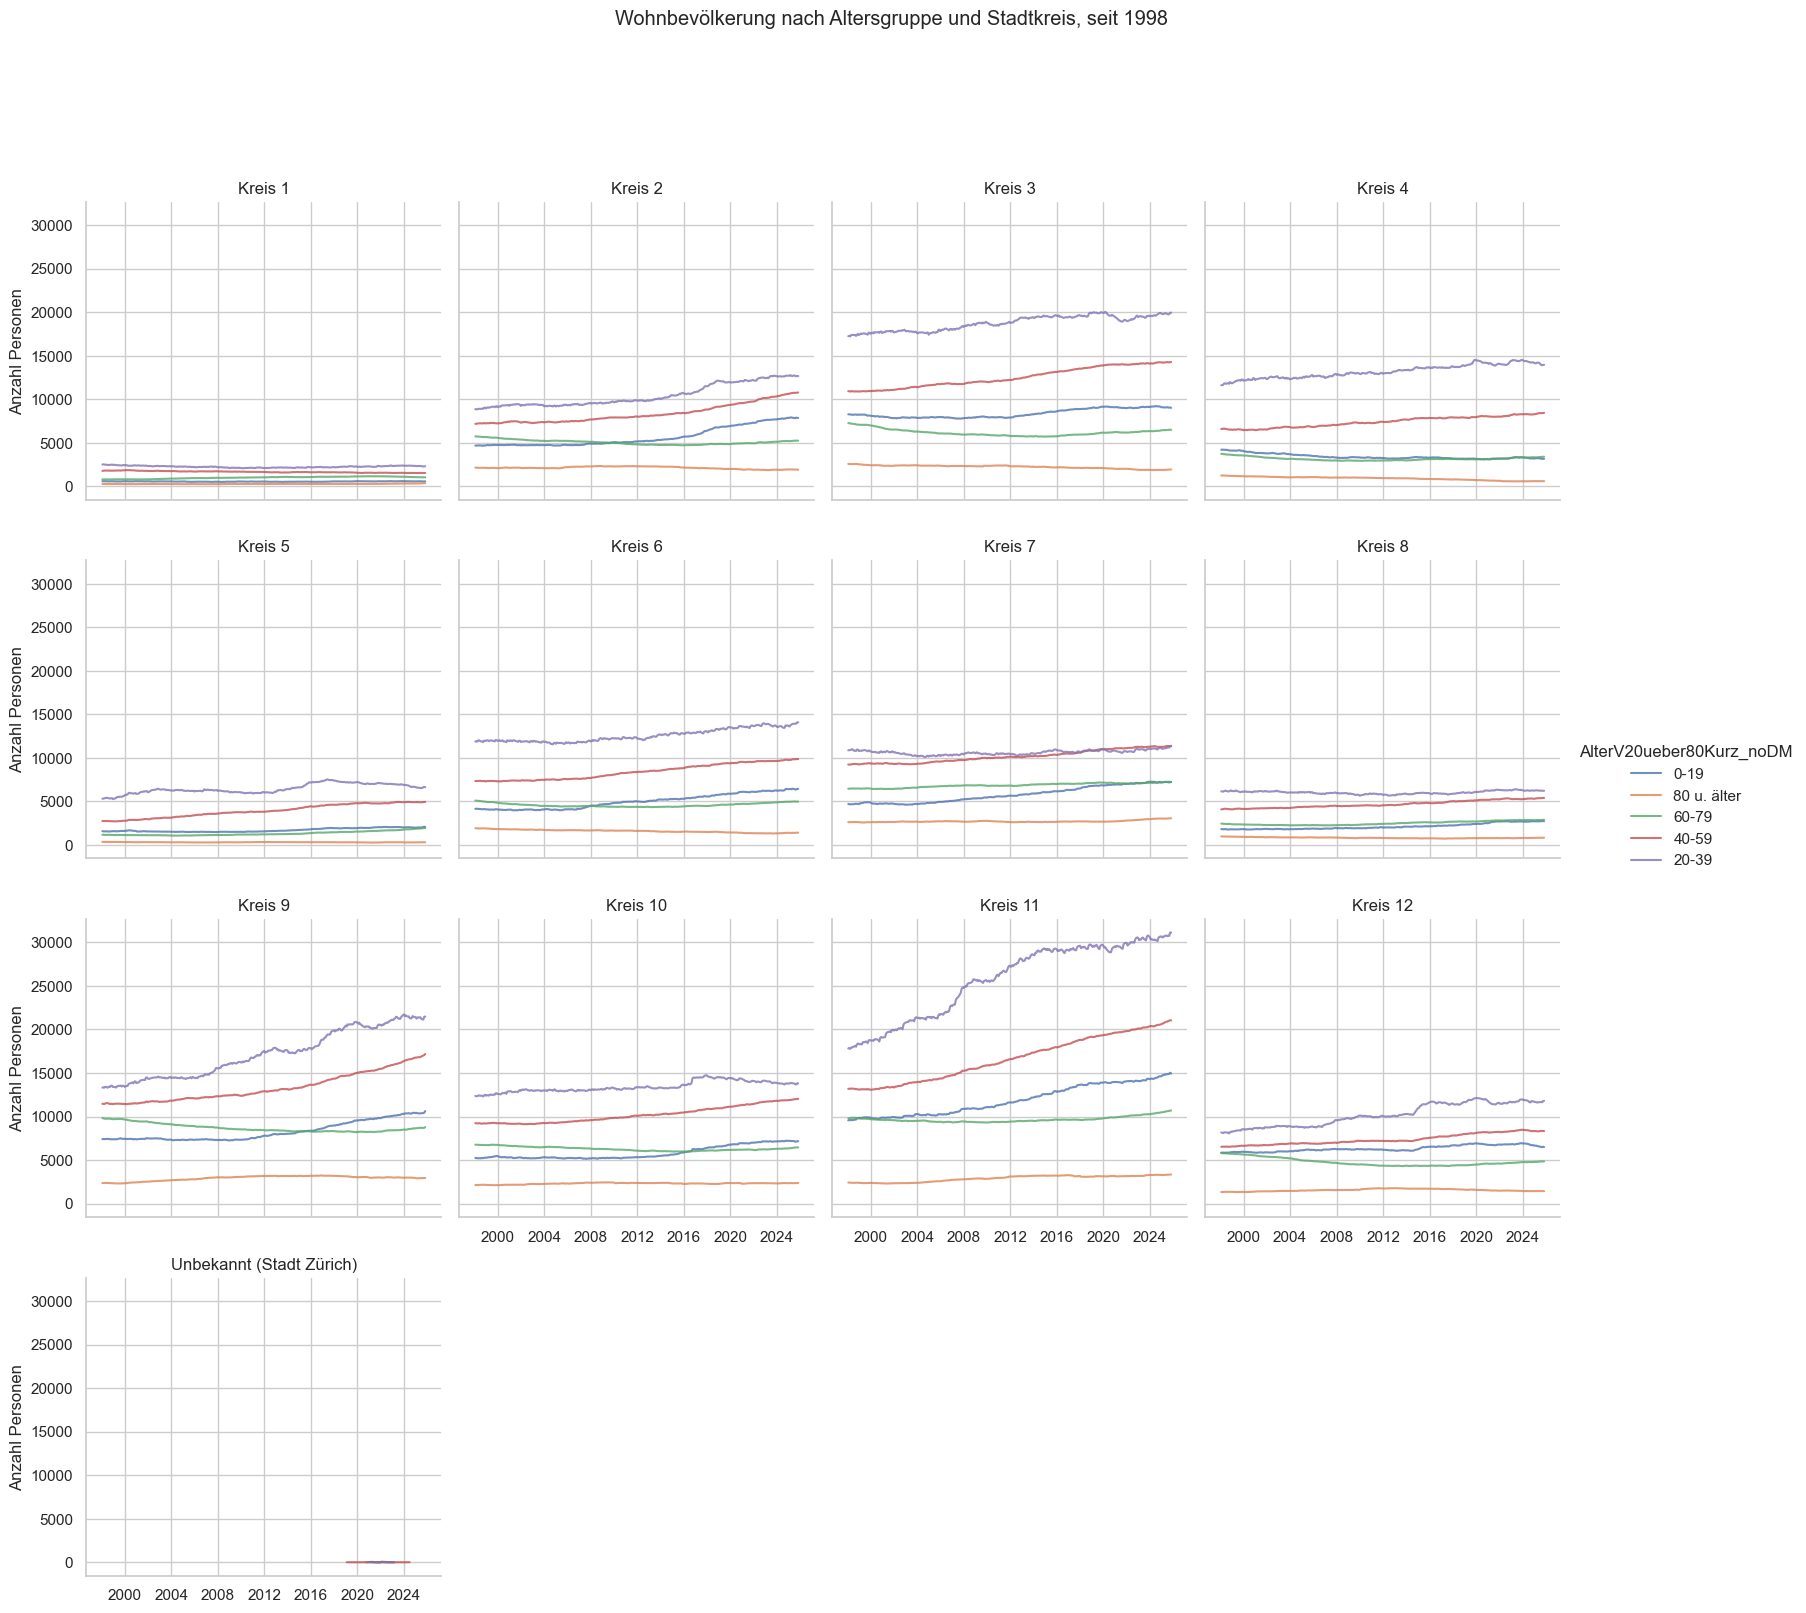

In [82]:
faced_grid2 = mypy_dv.plot_sns_facetgrid(
    data = myFG2.reset_index().sort_values('KreisCd', ascending=True)
    ,col = "KreisLang"
    ,hue = "AlterV20ueber80Kurz_noDM"
    ,col_wrap = 4
    ,grafiktyp = sns.lineplot
    ,x = "StichtagDat"
    ,y = "sum_WBev"
    ,ylabel= "Anzahl Personen"
    ,warning_status ="ignore"
    ,height = 3
    ,myTitle="Wohnbevölkerung nach Altersgruppe und Stadtkreis, seit "+str(int(data2betested.index.year.min()))
)
faced_grid2

### Daten in interaktiver Treemap zeigen
Dazu gibt es eine sehr nützliche Webseite https://plotly.com/python/treemaps/
Zu Farbskalen, siehe: https://plotly.com/python/builtin-colorscales/

**Funktion zum einfärben**

Muss ich noch als Funktion umsetzen 

In [83]:
  qual12br = ["#5D4BFE", "#4AA9FF", "#55FFFF", "#986AD5", "#FC4C99", "#FF919A", "#349894", "#44B14A", "#B7E14E", "#B97624", "#FF7231", "#FFD736"]
  qual12 = ["#3431DE", "#0A8DF6", "#23C3F1", "#7B4FB7", "#DB247D", "#FB737E", "#007C78", "#1F9E31", "#99C32E", "#9A5B01", "#FF720C", "#FBB900"]
  qual12da = ["#0017BF", "#0072D7", "#00A5D2", "#5E359A", "#BA0062", "#DA5563", "#00615D", "#00770F", "#7BA600", "#7B4100", "#DC5500", "#DA9C00"]
  div9val = ["#782600", "#CC4309", "#FF720C", "#FFBC88", "#E4E0DF", "#AECBFF", "#6B8EFF", "#3B51FF", "#2F2ABB",]
  div9ntr = ["#A30059", "#DB247D", "#FF579E", "#FFA8D0", "#E4E0DF", "#A8DBB1", "#55BC5D", "#1F9E31", "#10652A",]

In [84]:
# Extrahiere die Top-Fahrzeugmarken
color_var = data2betested['QuarLang'].unique().tolist()
# Verfügbare Farben
verfügbare_farben_zuericolors = div9ntr+qual12da+qual12br+qual12

# Erstelle das Farben-Dictionary
farben_dict_zc = {'(?)':'lightgrey'}
for index, x in enumerate(color_var):
    farben_dict_zc[x] = verfügbare_farben_zuericolors[index % len(verfügbare_farben_zuericolors)]

# Das resultierende Farben-Dictionary
print(farben_dict_zc)
#print(verfügbare_farben_zuericolors)

{'(?)': 'lightgrey', 'Rathaus': '#A30059', 'Fluntern': '#DB247D', 'Oberstrass': '#FF579E', 'Unterstrass': '#FFA8D0', 'Escher Wyss': '#E4E0DF', 'Gewerbeschule': '#A8DBB1', 'Hard': '#55BC5D', 'Langstrasse': '#1F9E31', 'Werd': '#10652A', 'Sihlfeld': '#0017BF', 'Friesenberg': '#0072D7', 'Seefeld': '#00A5D2', 'Alt-Wiedikon': '#5E359A', 'Leimbach': '#BA0062', 'Wollishofen': '#DA5563', 'City': '#00615D', 'Lindenhof': '#00770F', 'Hochschulen': '#7BA600', 'Hottingen': '#7B4100', 'Hirslanden': '#DC5500', 'Hirzenbach': '#DA9C00', 'Schwamendingen-Mitte': '#5D4BFE', 'Saatlen': '#4AA9FF', 'Seebach': '#55FFFF', 'Oerlikon': '#986AD5', 'Affoltern': '#FC4C99', 'Wipkingen': '#FF919A', 'Höngg': '#349894', 'Altstetten': '#44B14A', 'Albisrieden': '#B7E14E', 'Weinegg': '#B97624', 'Mühlebach': '#FF7231', 'Witikon': '#FFD736', 'Enge': '#3431DE', 'Unbekannt (Stadt Zürich)': '#0A8DF6'}


#### Aktueller Bestand der WBev nach Stadtkreis, Quartier, Alter und Herkunft

In [85]:
myTreemapAgg = data2betested.loc["2020":data_max_date]   \
    .groupby(['StichtagDat','StichtagDatJahr', 'StichtagDatMM', 'KreisLang','QuarLang','HerkunftLang', 'AlterV20ueber80Sort_noDM' , 'AlterV20ueber80Kurz_noDM' ]) \
    .agg(sum_WBev=('AnzBestWir', 'sum')) \
    .sort_values('StichtagDat', ascending=False) 

myTreemapAgg.reset_index().head(4)

#.query("KreisLang ='Unbekannt'")\


,StichtagDat,StichtagDatJahr,StichtagDatMM,KreisLang,QuarLang,HerkunftLang,AlterV20ueber80Sort_noDM,AlterV20ueber80Kurz_noDM,sum_WBev
0,2025-10-31,2025-01-01,10,Kreis 9,Altstetten,Schweizer*in,5,80 u. älter,1305
1,2025-10-31,2025-01-01,10,Kreis 12,Schwamendingen-Mitte,Schweizer*in,1,0-19,993
2,2025-10-31,2025-01-01,10,Kreis 12,Saatlen,Schweizer*in,3,40-59,1624
3,2025-10-31,2025-01-01,10,Kreis 12,Saatlen,Schweizer*in,4,60-79,934


In [86]:
time_slot = data_max_date

In [87]:
treeMap1 = mypy_dv.plot_px_treemap(
    data=myTreemapAgg.loc[time_slot].reset_index()
    ,levels=['KreisLang','QuarLang','HerkunftLang', 'AlterV20ueber80Kurz_noDM']
    ,values="sum_WBev"
    ,color="QuarLang"
    #, color_continuous_scale='Blues'
    ,color_discrete_map=farben_dict_zc
    #,color_discrete_map={'(?)':'lightgrey', 'Erwerbstätige':'#99C32E', 'Nichterwerbspersonen':'#7B4100', 'Erwerbslose':'#DB247D'}  
    ,height=600
    ,width=1100               
    #,margin_val_bottom=25
    ,myHeaderTitle="WBev nach Stadtkreis, Quartier, Alter und Herkunft, "+time_slot

)
treeMap1

path: [<plotly.express._special_inputs.Constant object at 0x00000233E21AB210>, 'KreisLang', 'QuarLang', 'HerkunftLang', 'AlterV20ueber80Kurz_noDM']
Typ von path: <class 'list'>


Kreisen Farben zuweisen

In [88]:
# Extrahiere die Top-Fahrzeugmarken
color_var = data2betested['KreisLang'].unique().tolist()
color_var = pd.Series(color_var).sort_values(ascending=False)
print(color_var)
# Verfügbare Farben
verfügbare_farben_zuericolors = div9ntr+qual12da+qual12br+qual12

# Erstelle das Farben-Dictionary
farben_dict_zc = {'(?)':'lightgrey'}
for index, x in enumerate(color_var):
    farben_dict_zc[x] = verfügbare_farben_zuericolors[index % len(verfügbare_farben_zuericolors)]

# Das resultierende Farben-Dictionary
print(farben_dict_zc)

12    Unbekannt (Stadt Zürich)
11                     Kreis 9
6                      Kreis 8
1                      Kreis 7
2                      Kreis 6
3                      Kreis 5
4                      Kreis 4
5                      Kreis 3
7                      Kreis 2
8                     Kreis 12
9                     Kreis 11
10                    Kreis 10
0                      Kreis 1
dtype: object
{'(?)': 'lightgrey', 'Unbekannt (Stadt Zürich)': '#A30059', 'Kreis 9': '#DB247D', 'Kreis 8': '#FF579E', 'Kreis 7': '#FFA8D0', 'Kreis 6': '#E4E0DF', 'Kreis 5': '#A8DBB1', 'Kreis 4': '#55BC5D', 'Kreis 3': '#1F9E31', 'Kreis 2': '#10652A', 'Kreis 12': '#0017BF', 'Kreis 11': '#0072D7', 'Kreis 10': '#00A5D2', 'Kreis 1': '#5E359A'}


In [89]:
treeMap2 = mypy_dv.plot_px_treemap(
    data=myTreemapAgg.loc[time_slot].reset_index().sort_values("AlterV20ueber80Sort_noDM", ascending=True)
    ,levels=['AlterV20ueber80Kurz_noDM','KreisLang','QuarLang','HerkunftLang']
    ,values="sum_WBev"
    ,color="KreisLang"
    #, color_continuous_scale='Blues'
    ,color_discrete_map=farben_dict_zc
    ,height=600
    ,width=1100               
    #,margin_val_bottom=25
    ,myHeaderTitle="WBev nach Stadtkreis, Quartier, Alter und Herkunft, "+time_slot

)
treeMap2

path: [<plotly.express._special_inputs.Constant object at 0x00000233E226F6D0>, 'AlterV20ueber80Kurz_noDM', 'KreisLang', 'QuarLang', 'HerkunftLang']
Typ von path: <class 'list'>


In [90]:
treeMap3 = mypy_dv.plot_px_treemap(
    data=myTreemapAgg.loc[time_slot].reset_index().sort_values("AlterV20ueber80Sort_noDM", ascending=True)
    ,levels=['HerkunftLang','KreisLang','QuarLang', 'AlterV20ueber80Kurz_noDM']
    ,values="sum_WBev"
    ,color="KreisLang"
    #, color_continuous_scale='Blues'
    ,color_discrete_map=farben_dict_zc
    ,height=600
    ,width=1100               
    #,margin_val_bottom=25
    ,myHeaderTitle="WBev nach Stadtkreis, Quartier, Alter und Herkunft, "+time_slot

)
treeMap3

path: [<plotly.express._special_inputs.Constant object at 0x00000233E0ED9750>, 'HerkunftLang', 'KreisLang', 'QuarLang', 'AlterV20ueber80Kurz_noDM']
Typ von path: <class 'list'>


Liniendiagramm 
[Link zur Doku](https://altair-viz.github.io/gallery/multiline_highlight.html)

### Test: Choroplethenkarte
Importiere die Geodaten als GeoJSON

In [91]:
# Read abt. Geopandas https://geopandas.org/docs/user_guide/io.html
# Wenn die Daten lokal agelegt sind, dann kannst Du folgendes machen:
##input_stadtquartiere = r"//szh.loc/ssz/data/GIS/Daten/Vektor/_aktuell/stzh.adm_statistische_quartiere_map.json"
##df_stadtquartiere = gpd.read_file(input_stadtquartiere)
##df_stadtquartiere.head(2)
#df_stadtkreise.dtypes

geojson_url = "https://www.ogd.stadt-zuerich.ch/wfs/geoportal/Statistische_Quartiere?service=WFS&version=1.1.0&request=GetFeature&outputFormat=GeoJSON&typename=adm_statistische_quartiere_map"
df_adm_statistische_quartiere_map = gpd.read_file(geojson_url)

df_adm_statistische_quartiere_map.head(5)


,id,geometrie_gdo,kname,knr,objectid,qname,qnr,geometry
0,adm_statistische_quartiere_map.1,None,Kreis 7,7,1,Hirslanden,73,"POLYGON ((8.55670 47.36406, 8.55682 47.36410, ..."
1,adm_statistische_quartiere_map.2,None,Kreis 8,8,2,Weinegg,83,"POLYGON ((8.55670 47.36405, 8.55672 47.36403, ..."
2,adm_statistische_quartiere_map.3,None,Kreis 8,8,3,Mühlebach,82,"POLYGON ((8.55423 47.36456, 8.55426 47.36452, ..."
3,adm_statistische_quartiere_map.4,None,Kreis 8,8,4,Seefeld,81,"POLYGON ((8.54795 47.36500, 8.54805 47.36489, ..."
4,adm_statistische_quartiere_map.7,None,Kreis 4,4,7,Werd,41,"POLYGON ((8.53300 47.37394, 8.53299 47.37392, ..."


Joine die importierten statistischen Daten des aktuellen Jahres zum Geodatensatz:

*Siehe dazu Doku zu [Geopandas](https://geopandas.org/docs/user_guide/mergingdata.html)*

In [92]:
akt_wbev_quart = data2betested.loc[data_max_date].groupby(
    ['StichtagDat','StichtagDatMM','QuarCd','QuarLang']
).agg(
    {'AnzBestWir':'sum'}
)
akt_wbev_quart.head()


AnzBestWir
StichtagDat StichtagDatMM QuarCd QuarLang               
2025-10-31  10            11     Rathaus            3282
                          12     Hochschulen         696
                          13     Lindenhof          1026
                          14     City                775
                          21     Wollishofen       22044

In [93]:
# Rename attribute stznr to StatZoneSort, so the IDs have the same name
stadtquartiere_shapes = df_adm_statistische_quartiere_map[['geometry', 'qnr', 'qname', 'knr']].rename(columns={'qnr': 'QuarCd'})

# Merge with `merge` method on shared variable (stznr und StatZoneSort):
stadtquartiere_shapes_joined = stadtquartiere_shapes.merge(akt_wbev_quart, on='QuarCd')

stadtquartiere_shapes_joined.head(2)


,geometry,QuarCd,qname,knr,AnzBestWir
0,"POLYGON ((8.55670 47.36406, 8.55682 47.36410, ...",73,Hirslanden,7,7660
1,"POLYGON ((8.55670 47.36405, 8.55672 47.36403, ...",83,Weinegg,8,5746


c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

c:\Users\sszsim\AppData\Local\anaconda3\envs\gogo_stuff\Lib\site-packages\mapclassify\classifiers.py:1860: UserWarning:

Numba not installed. Using slow pure python version.



<Axes: >

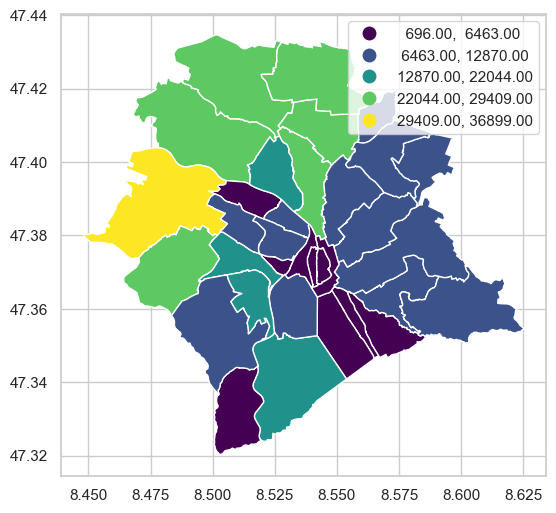

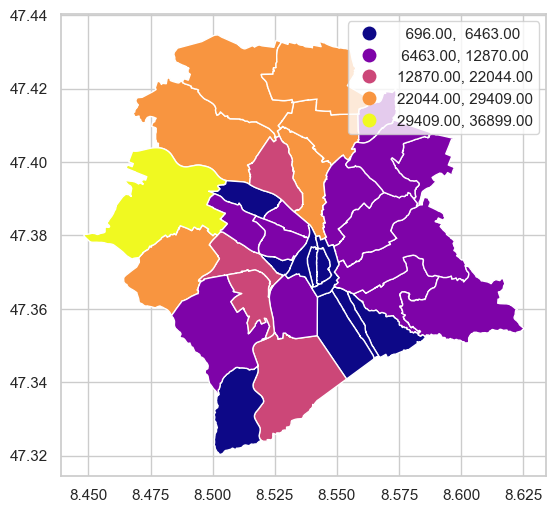

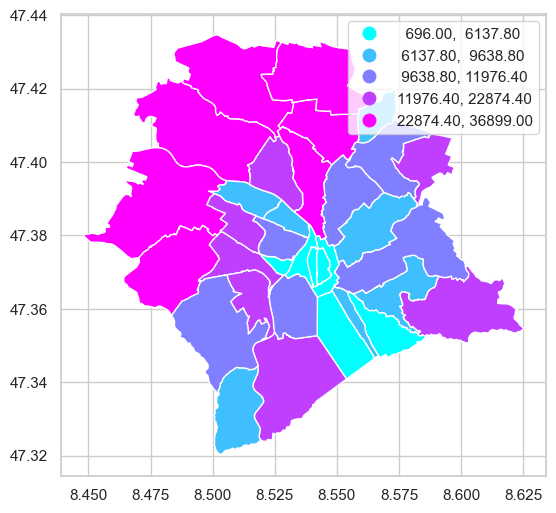

In [94]:
# Plot by StatQuartiere
# Weitere Schemes: scheme='quantiles', scheme='fisherjenks', scheme='natural_breaks',

stadtquartiere_shapes_joined.plot(column='AnzBestWir', cmap='viridis', scheme='natural_breaks', legend=True )
#scheme werte: https://matplotlib.org/2.0.2/users/colormaps.html

stadtquartiere_shapes_joined.plot(column='AnzBestWir', cmap='plasma', scheme='fisherjenks', legend=True )
#scheme werte: https://matplotlib.org/2.0.2/users/colormaps.html
stadtquartiere_shapes_joined.plot(column='AnzBestWir', cmap='cool', scheme='quantiles', legend=True )
#scheme werte: https://matplotlib.org/2.0.2/users/colormaps.html

#
#Neuere Gallerie: https://matplotlib.org/stable/gallery/index.html

Noch zu prüfen, folgendes schöne Beispiel: https://docs.bokeh.org/en/latest/docs/user_guide/interaction/legends.html

Konkrete Beispiele von Bookeh in Jupyter NB: https://docs.bokeh.org/en/latest/docs/user_guide/jupyter.html

**Sharepoint als gecheckt markieren!**

Record auf Sharepoint: 

- **[Link](https://szhglobal.sharepoint.com/sites/ssz-spo-produkte/Lists/SASA_Outputs/DispForm.aspx?ID=489&e=4HKONv)**

- **[Früherer Link](http://kollaboration.intranet.stzh.ch/orga/ssz-produkte/Lists/SASA_Outputs/EditForm.aspx?ID=157&Source=%2Forga%2Fssz%2Dprodukte%2FLists%2FSASA%5FOutputs)**